<a href="https://colab.research.google.com/github/dalilahbiamby/FMNISTandMNIST_Experiments/blob/main/Dense_Sparse_Experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
#Cell 1: Set up and GPU verification

import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import sklearn
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report
import scipy
from scipy.optimize import curve_fit
import cv2, gc, json, warnings
warnings.filterwarnings('ignore')

# Software versions
print("SOFTWARE VERSIONS")
print("Python      :", sys.version.split()[0])
print("TensorFlow  :", tf.__version__)
print("Keras       :", keras.__version__)
print("NumPy       :", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("SciPy       :", scipy.__version__)
print("OpenCV      :", cv2.__version__)
print("Matplotlib  :", matplotlib.__version__)

# Check GPU availability on Colab
gpus = tf.config.list_physical_devices('GPU')
print("GPU available:", gpus if gpus else "None — check Runtime > Change runtime type")

# Global seeds ensure reproducibility across all runs
tf.random.set_seed(42)
#np.random.seed(42)

SOFTWARE VERSIONS
Python      : 3.12.13
TensorFlow  : 2.20.0
Keras       : 3.13.2
NumPy       : 2.0.2
scikit-learn: 1.6.1
SciPy       : 1.16.3
OpenCV      : 4.13.0
Matplotlib  : 3.10.0
GPU available: None — check Runtime > Change runtime type


In [2]:
#Cell 2: Experiment configuration

# Seven training subset sizes: 1% to 100% of 60,000 images
SAMPLE_SIZES       = [600, 3000, 6000, 15000, 30000, 45000, 60000]
SAMPLE_PERCENTAGES = ["1%", "5%", "10%", "25%", "50%", "75%", "100%"]

# Baseline configuration (2x2 kernels throughout)
BASELINE_CONFIG = {
    "name":        "baseline",
    "lr":          0.001,
    "batch_size":  64,
    "dropout":     0.3,
    "optimizer":   "adam",
    "dense_units": 128,
    "kernel_size": 2,
}

N_SEEDS          = 3        # seeds 0, 1, 2
EPOCHS           = 25
VALIDATION_SPLIT = 0.1

FMNIST_CLASS_NAMES = [
    "T-shirt/Top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"
]

# Kernel pattern configurations: mask value 1 = active position, 0 = zeroed.
# Central is not defined for 2x2 (no single centre pixel).
KERNEL_CONFIGS = [
    {"name": "dense_2x2",    "pattern": "dense",
     "kernel_size": 2, "mask": np.ones((2, 2), dtype=np.float32),
     "desc": "All positions (2×2)"},
    {"name": "dense_3x3",    "pattern": "dense",
     "kernel_size": 3, "mask": np.ones((3, 3), dtype=np.float32),
     "desc": "All positions (3×3)"},
    {"name": "dense_4x4",    "pattern": "dense",
     "kernel_size": 4, "mask": np.ones((4, 4), dtype=np.float32),
     "desc": "All positions (4×4)"},

    {"name": "edge_2x2",     "pattern": "edge",
     "kernel_size": 2,
     "mask": np.array([[1, 1], [0, 0]], dtype=np.float32),
     "desc": "Top-row edge (2×2)"},
    {"name": "edge_3x3",     "pattern": "edge",
     "kernel_size": 3,
     "mask": np.array([[1,1,1],[1,0,1],[1,1,1]], dtype=np.float32),
     "desc": "Border ring (3×3)"},
    {"name": "edge_4x4",     "pattern": "edge",
     "kernel_size": 4,
     "mask": np.array([[1,1,1,1],[1,0,0,1],[1,0,0,1],[1,1,1,1]], dtype=np.float32),
     "desc": "Border ring (4×4)"},

    {"name": "diagonal_2x2", "pattern": "diagonal",
     "kernel_size": 2,
     "mask": np.array([[1, 0], [0, 1]], dtype=np.float32),
     "desc": "Main diagonal (2×2)"},
    {"name": "diagonal_3x3", "pattern": "diagonal",
     "kernel_size": 3,
     "mask": np.array([[1,0,1],[0,0,0],[1,0,1]], dtype=np.float32),
     "desc": "Four corners (3×3)"},
    {"name": "diagonal_4x4", "pattern": "diagonal",
     "kernel_size": 4,
     "mask": np.array([[1,0,0,1],[0,0,0,0],[0,0,0,0],[1,0,0,1]], dtype=np.float32),
     "desc": "Four corners (4×4)"},

    {"name": "central_3x3",  "pattern": "central",
     "kernel_size": 3,
     "mask": np.array([[0,0,0],[0,1,0],[0,0,0]], dtype=np.float32),
     "desc": "Centre pixel (3×3)"},
    {"name": "central_4x4",  "pattern": "central",
     "kernel_size": 4,
     "mask": np.array([[0,0,0,0],[0,1,1,0],[0,1,1,0],[0,0,0,0]], dtype=np.float32),
     "desc": "Inner 2×2 centre (4×4)"},
]

KERNEL_SIZE_OPTIONS = [2, 3, 4]
PATTERN_TYPES       = ["dense", "edge", "diagonal", "central"]
print(f"Kernel configurations: {len(KERNEL_CONFIGS)} total")
for kc in KERNEL_CONFIGS:
    active = int(kc["mask"].sum())
    print(f"  {kc['name']:<14}  {active:>2} active positions  — {kc['desc']}")

# Coordinate array lengths for the sparse pipeline, set just above the
# 99th percentile of active-pixel counts so <1% of images are truncated.
MAX_ACTIVE_FM = 260   # Fashion-MNIST outlines are denser
MAX_ACTIVE_MN = 120   # MNIST outlines are sparser

print("Configuration ready.")

Kernel configurations: 11 total
  dense_2x2        4 active positions  — All positions (2×2)
  dense_3x3        9 active positions  — All positions (3×3)
  dense_4x4       16 active positions  — All positions (4×4)
  edge_2x2         2 active positions  — Top-row edge (2×2)
  edge_3x3         8 active positions  — Border ring (3×3)
  edge_4x4        12 active positions  — Border ring (4×4)
  diagonal_2x2     2 active positions  — Main diagonal (2×2)
  diagonal_3x3     4 active positions  — Four corners (3×3)
  diagonal_4x4     4 active positions  — Four corners (4×4)
  central_3x3      1 active positions  — Centre pixel (3×3)
  central_4x4      4 active positions  — Inner 2×2 centre (4×4)
Configuration ready.


In [3]:
#Cell 3: Data loading and preprocessing functions

def load_and_preprocess(dataset_name):
    """Load a dataset, scale pixels to [0,1], add channel dim -> (N, 28, 28, 1)."""
    if dataset_name == "fashion_mnist":
        (X_tr, y_tr), (X_te, y_te) = keras.datasets.fashion_mnist.load_data()
    else:
        (X_tr, y_tr), (X_te, y_te) = keras.datasets.mnist.load_data()
    X_tr = (X_tr.astype("float32") / 255.0)[..., np.newaxis]
    X_te = (X_te.astype("float32") / 255.0)[..., np.newaxis]
    print(f"  {dataset_name.upper()}: train {X_tr.shape}, test {X_te.shape}")
    return X_tr, y_tr, X_te, y_te


def make_edge_outlines(images, min_contour_area=10):
    """Convert images to external-contour-only binary outlines:
    Otsu threshold -> morphological closing -> external contour
    extraction -> noise filter -> one-pixel-wide outline on black."""
    uint8    = (images.squeeze(-1) * 255).astype(np.uint8)
    outlines = np.zeros_like(uint8, dtype=np.float32)
    kernel   = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2))

    for i in range(len(uint8)):
        img = uint8[i]

        # Otsu picks the threshold per image from its intensity histogram
        _, binary = cv2.threshold(
            img, 0, 255,
            cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # Close small gaps in the foreground mask before tracing contours
        binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

        # Outermost contours only
        contours, _ = cv2.findContours(
            binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

        # Drop noise blobs below the minimum area
        contours = [c for c in contours if cv2.contourArea(c) >= min_contour_area]

        canvas = np.zeros_like(img)
        if contours:
            contours = sorted(contours, key=cv2.contourArea, reverse=True)
            cv2.drawContours(canvas, contours, -1, 255, 1)

        outlines[i] = (canvas > 0).astype(np.float32)

    return outlines[..., np.newaxis]


def stratified_sample(images, labels, n_samples, seed):
    """Draw a class-proportional subset via StratifiedShuffleSplit."""
    if n_samples >= len(images):
        return images, labels
    sss = StratifiedShuffleSplit(n_splits=1, train_size=n_samples, random_state=seed)
    idx, _ = next(sss.split(images, labels))
    return images[idx], labels[idx]


def extract_coords(outlines, max_active):
    """Extract (row, col) of non-zero pixels per image into a fixed-length
    array padded with -1. Overflow is truncated in row-major order."""
    N      = len(outlines)
    coords = np.full((N, max_active, 2), -1, dtype=np.int32)
    n_trunc = 0
    for i in range(N):
        rows, cols = np.nonzero(outlines[i, :, :, 0])
        n = len(rows)
        if n > max_active:
            n_trunc += 1
            rows, cols, n = rows[:max_active], cols[:max_active], max_active
        coords[i, :n, 0] = rows
        coords[i, :n, 1] = cols
    if n_trunc:
        pct = 100 * n_trunc / N
        print(f"  Truncated {n_trunc}/{N} images ({pct:.1f}%)")
    return coords


def _get_optimizer(config):
    if config["optimizer"] == "adam":
        return keras.optimizers.Adam(learning_rate=config["lr"])
    return keras.optimizers.SGD(learning_rate=config["lr"], momentum=0.9)

Loading fashion_mnist for visualisation...
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
  FASHION_MNIST: train (60000, 28, 28, 1), test (10000, 28, 28, 1)


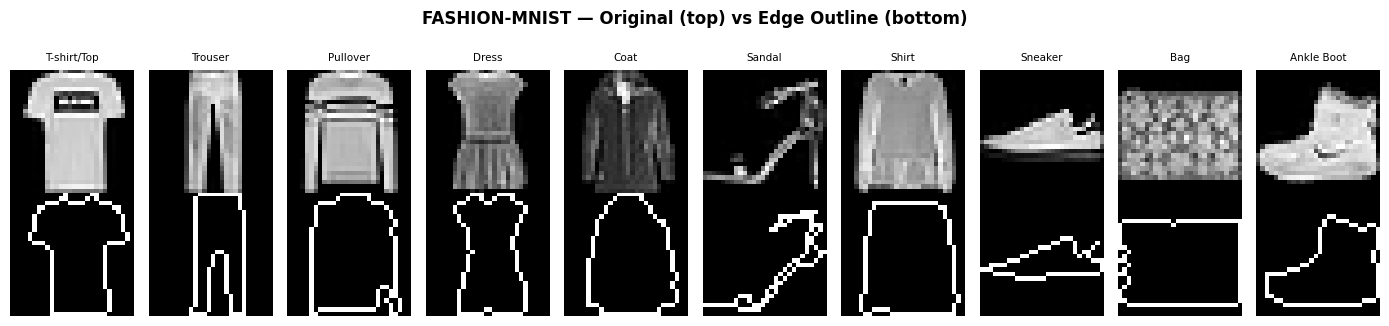

Saved: vis_edge_fashion_mnist.png
Loading mnist for visualisation...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
  MNIST: train (60000, 28, 28, 1), test (10000, 28, 28, 1)


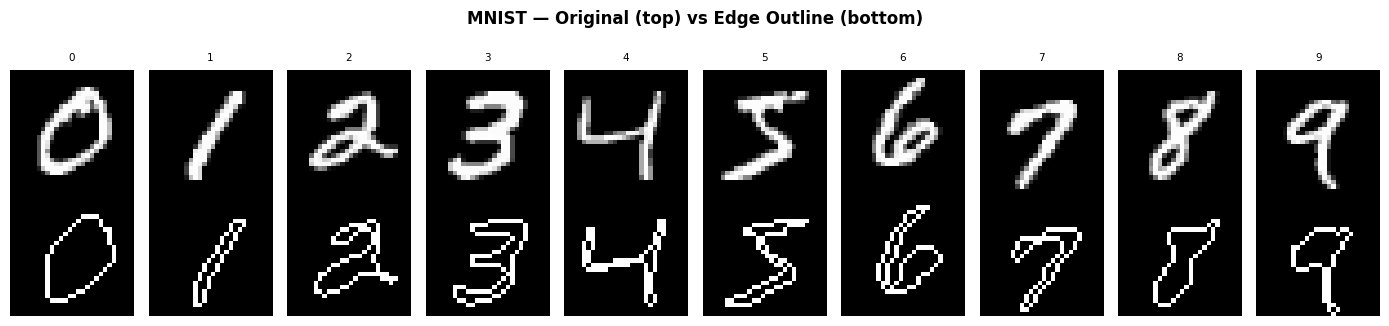

Saved: vis_edge_mnist.png


In [ ]:
#Cell 4: Visualise original vs contour outline images

def visualise_edge_outlines(dataset_name):
    """Grid of original images (top row) vs contour outlines (bottom row),
    one example per class."""
    print(f"Loading {dataset_name} for visualisation...")
    X_tr, y_tr, _, _ = load_and_preprocess(dataset_name)
    X_edges = make_edge_outlines(X_tr)
    n_classes    = 10
    class_names  = FMNIST_CLASS_NAMES if dataset_name == "fashion_mnist" \
                   else [str(i) for i in range(10)]
    ds_label     = dataset_name.replace("_", "-").upper()

    fig, axes = plt.subplots(2, n_classes, figsize=(14, 3.2))
    fig.suptitle(f"{ds_label} — Original (top) vs Contour Outline (bottom)",
                 fontsize=12, fontweight="bold", y=1.01)
    for cls in range(n_classes):
        idx = np.where(y_tr == cls)[0][0]
        axes[0, cls].imshow(X_tr[idx, :, :, 0],    cmap="gray", vmin=0, vmax=1)
        axes[1, cls].imshow(X_edges[idx, :, :, 0], cmap="gray", vmin=0, vmax=1)
        axes[0, cls].set_title(class_names[cls], fontsize=7.5)
        for row in range(2):
            axes[row, cls].axis("off")
    axes[0, 0].set_ylabel("Original",         fontsize=9, labelpad=3)
    axes[1, 0].set_ylabel("Contour\nOutline", fontsize=9, labelpad=3)
    plt.tight_layout()
    fname = f"vis_edge_{dataset_name}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

visualise_edge_outlines("fashion_mnist")
visualise_edge_outlines("mnist")

In [4]:
#Cell 5: Model architectures

#MaskedConv2D: kernel pattern experiments

class MaskedConv2D(layers.Layer):
    """Conv2D whose kernel is multiplied by a fixed binary mask on every
    forward pass. Masked positions stay at zero; unmasked weights train
    normally. The mask itself is not trainable."""
    def __init__(self, filters, mask_2d, activation=None, padding="same", **kwargs):
        super().__init__(**kwargs)
        self.filters    = filters
        self.mask_2d    = np.array(mask_2d, dtype=np.float32)
        self.activation = keras.activations.get(activation)
        self.padding    = padding

    def build(self, input_shape):
        in_ch = input_shape[-1]
        k     = self.mask_2d.shape[0]
        self.kernel = self.add_weight(
            shape=(k, k, in_ch, self.filters),
            initializer="glorot_uniform", trainable=True, name="kernel")
        self.bias = self.add_weight(
            shape=(self.filters,), initializer="zeros", trainable=True, name="bias")
        # Expand mask to broadcast over in_channels and filters
        self.mask_t = tf.constant(
            self.mask_2d[:, :, np.newaxis, np.newaxis], dtype=tf.float32)

    def call(self, inputs):
        effective = self.kernel * self.mask_t
        x = tf.nn.conv2d(inputs, effective,
                          strides=[1,1,1,1], padding=self.padding.upper())
        x = tf.nn.bias_add(x, self.bias)
        return self.activation(x) if self.activation else x


#Dense CNN builders

def build_dense_cnn(config=BASELINE_CONFIG, num_classes=10):
    """Two-block shallow CNN. Kernel size comes from config so the same
    builder serves all OFAT variants."""
    k = config["kernel_size"]
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, (k, k), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (k, k), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(config["dense_units"], activation="relu"),
        layers.Dropout(config["dropout"]),
        layers.Dense(num_classes, activation="softmax"),
    ], name=f"dense_{config['name']}")
    model.compile(optimizer=_get_optimizer(config),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model


def build_masked_dense_cnn(kc, base_config=BASELINE_CONFIG, num_classes=10):
    """kc is one entry from KERNEL_CONFIGS."""
    mask = kc["mask"]
    cfg  = {**base_config, "kernel_size": kc["kernel_size"]}
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        MaskedConv2D(32, mask, activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        MaskedConv2D(64, mask, activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(cfg["dense_units"], activation="relu"),
        layers.Dropout(cfg["dropout"]),
        layers.Dense(num_classes, activation="softmax"),
    ], name=f"masked_{kc['name']}")
    model.compile(optimizer=_get_optimizer(cfg),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model


# SparseConv2D layer

class SparseConv2D(layers.Layer):
    """Convolution computed only at active pixel coordinates (submanifold
    sparse convolution). Per active coordinate: gather the k×k neighbourhood
    from the zero-padded input, apply the optional kernel mask, multiply by
    the shared weight matrix, and scatter the result back into a full
    feature map. Padding coordinates (-1) are excluded via a validity mask."""
    def __init__(self, filters, kernel_size, activation=None,
                 kernel_mask=None, **kwargs):
        super().__init__(**kwargs)
        self.filters        = filters
        self.kernel_size    = kernel_size
        self.activation     = keras.activations.get(activation)
        self.kernel_mask_np = kernel_mask  # optional (k,k) binary mask

    def build(self, input_shape):
        images_shape, _ = input_shape
        in_ch = images_shape[-1]
        k     = self.kernel_size
        self.kernel = self.add_weight(
            shape=(k * k * in_ch, self.filters),
            initializer="glorot_uniform", trainable=True, name="kernel")
        self.bias = self.add_weight(
            shape=(self.filters,), initializer="zeros", trainable=True, name="bias")
        # Flatten the mask to match the gathered patch dimension (k*k*in_ch)
        if self.kernel_mask_np is not None:
            flat = self.kernel_mask_np.flatten()
            flat = np.repeat(flat, in_ch).astype(np.float32)
            self.mask_vec = tf.constant(flat, dtype=tf.float32)
        else:
            self.mask_vec = None

    def call(self, inputs):
        images, coords = inputs
        k   = self.kernel_size
        pad = k // 2
        H   = images.shape[1]
        W   = images.shape[2]
        padded = tf.pad(images, [[0,0],[pad,pad],[pad,pad],[0,0]])

        def process_one(args):
            img_p, coord = args
            valid = tf.reduce_all(coord >= 0, axis=-1)   # -1 rows are padding
            safe  = tf.maximum(coord, 0)
            rows  = safe[:, 0] + pad
            cols  = safe[:, 1] + pad
            patches = []
            for dr in range(k):
                for dc in range(k):
                    idx = tf.stack([rows - pad + dr, cols - pad + dc], axis=-1)
                    patches.append(tf.gather_nd(img_p, idx))
            patch_tensor = tf.concat(patches, axis=-1)    # (M, k*k*in_ch)
            if self.mask_vec is not None:
                patch_tensor = patch_tensor * self.mask_vec
            out = tf.matmul(patch_tensor, self.kernel) + self.bias
            out = out * tf.cast(valid, tf.float32)[:, None]
            return tf.tensor_scatter_nd_add(
                tf.zeros((H, W, self.filters), dtype=tf.float32),
                tf.cast(safe, tf.int32), out)

        outputs = tf.map_fn(process_one, (padded, coords),
                            fn_output_signature=tf.float32)
        outputs.set_shape((None, H, W, self.filters))
        return self.activation(outputs) if self.activation else outputs


def build_sparse_cnn(config=BASELINE_CONFIG, max_active=MAX_ACTIVE_FM,
                     num_classes=10, kernel_mask=None):
    """Sparse two-block CNN mirroring the dense baseline. Both SparseConv2D
    layers share the same active-coordinate input."""
    k        = config["kernel_size"]
    img_in   = layers.Input(shape=(28, 28, 1),       name="image")
    coord_in = layers.Input(shape=(max_active, 2),
                             dtype="int32",            name="coords")

    x   = SparseConv2D(32, k, activation="relu",
                        kernel_mask=kernel_mask)([img_in, coord_in])
    x   = SparseConv2D(64, k, activation="relu",
                        kernel_mask=kernel_mask)([x, coord_in])
    x   = layers.MaxPooling2D((2, 2))(x)
    x   = layers.MaxPooling2D((2, 2))(x)
    x   = layers.Flatten()(x)
    x   = layers.Dense(config["dense_units"], activation="relu")(x)
    x   = layers.Dropout(config["dropout"])(x)
    out = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs=[img_in, coord_in], outputs=out,
                        name=f"sparse_{config['name']}")
    model.compile(optimizer=_get_optimizer(config),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model


print("Dense CNN (baseline)")
build_dense_cnn().summary()

Dense CNN (baseline)


Model: "dense_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 411,242 (1.57 MB)

 Trainable params: 411,242 (1.57 MB)

 Non-trainable params: 0 (0.00 B)

  FASHION_MNIST: train (60000, 28, 28, 1), test (10000, 28, 28, 1)

=== PATTERN EXPERIMENT: FASHION_MNIST ===
  [dense] dense_2x2: All positions (2×2)
    → 0.9156 ± 0.0030
  [dense] dense_3x3: All positions (3×3)
    → 0.9192 ± 0.0047
  [dense] dense_4x4: All positions (4×4)
    → 0.9186 ± 0.0014
  [dense] edge_2x2: Top-row edge (2×2)
    → 0.9067 ± 0.0007
  [dense] edge_3x3: Border ring (3×3)
    → 0.9184 ± 0.0012
  [dense] edge_4x4: Border ring (4×4)
    → 0.9174 ± 0.0036
  [dense] diagonal_2x2: Main diagonal (2×2)
    → 0.9002 ± 0.0022
  [dense] diagonal_3x3: Four corners (3×3)
    → 0.9096 ± 0.0040
  [dense] diagonal_4x4: Four corners (4×4)
    → 0.9110 ± 0.0023
  [dense] central_3x3: Centre pixel (3×3)
    → 0.8784 ± 0.0033
  [dense] central_4x4: Inner 2×2 centre (4×4)
    → 0.9126 ± 0.0024
  [sparse] dense_2x2: All positions (2×2)
    → 0.8421 ± 0.0020
  [sparse] dense_3x3: All positions (3×3)
    → 0.8531 ± 0.0012
  [sparse] dense_4x4: All positions (4×4)
    → 0.8537 ± 0.0007


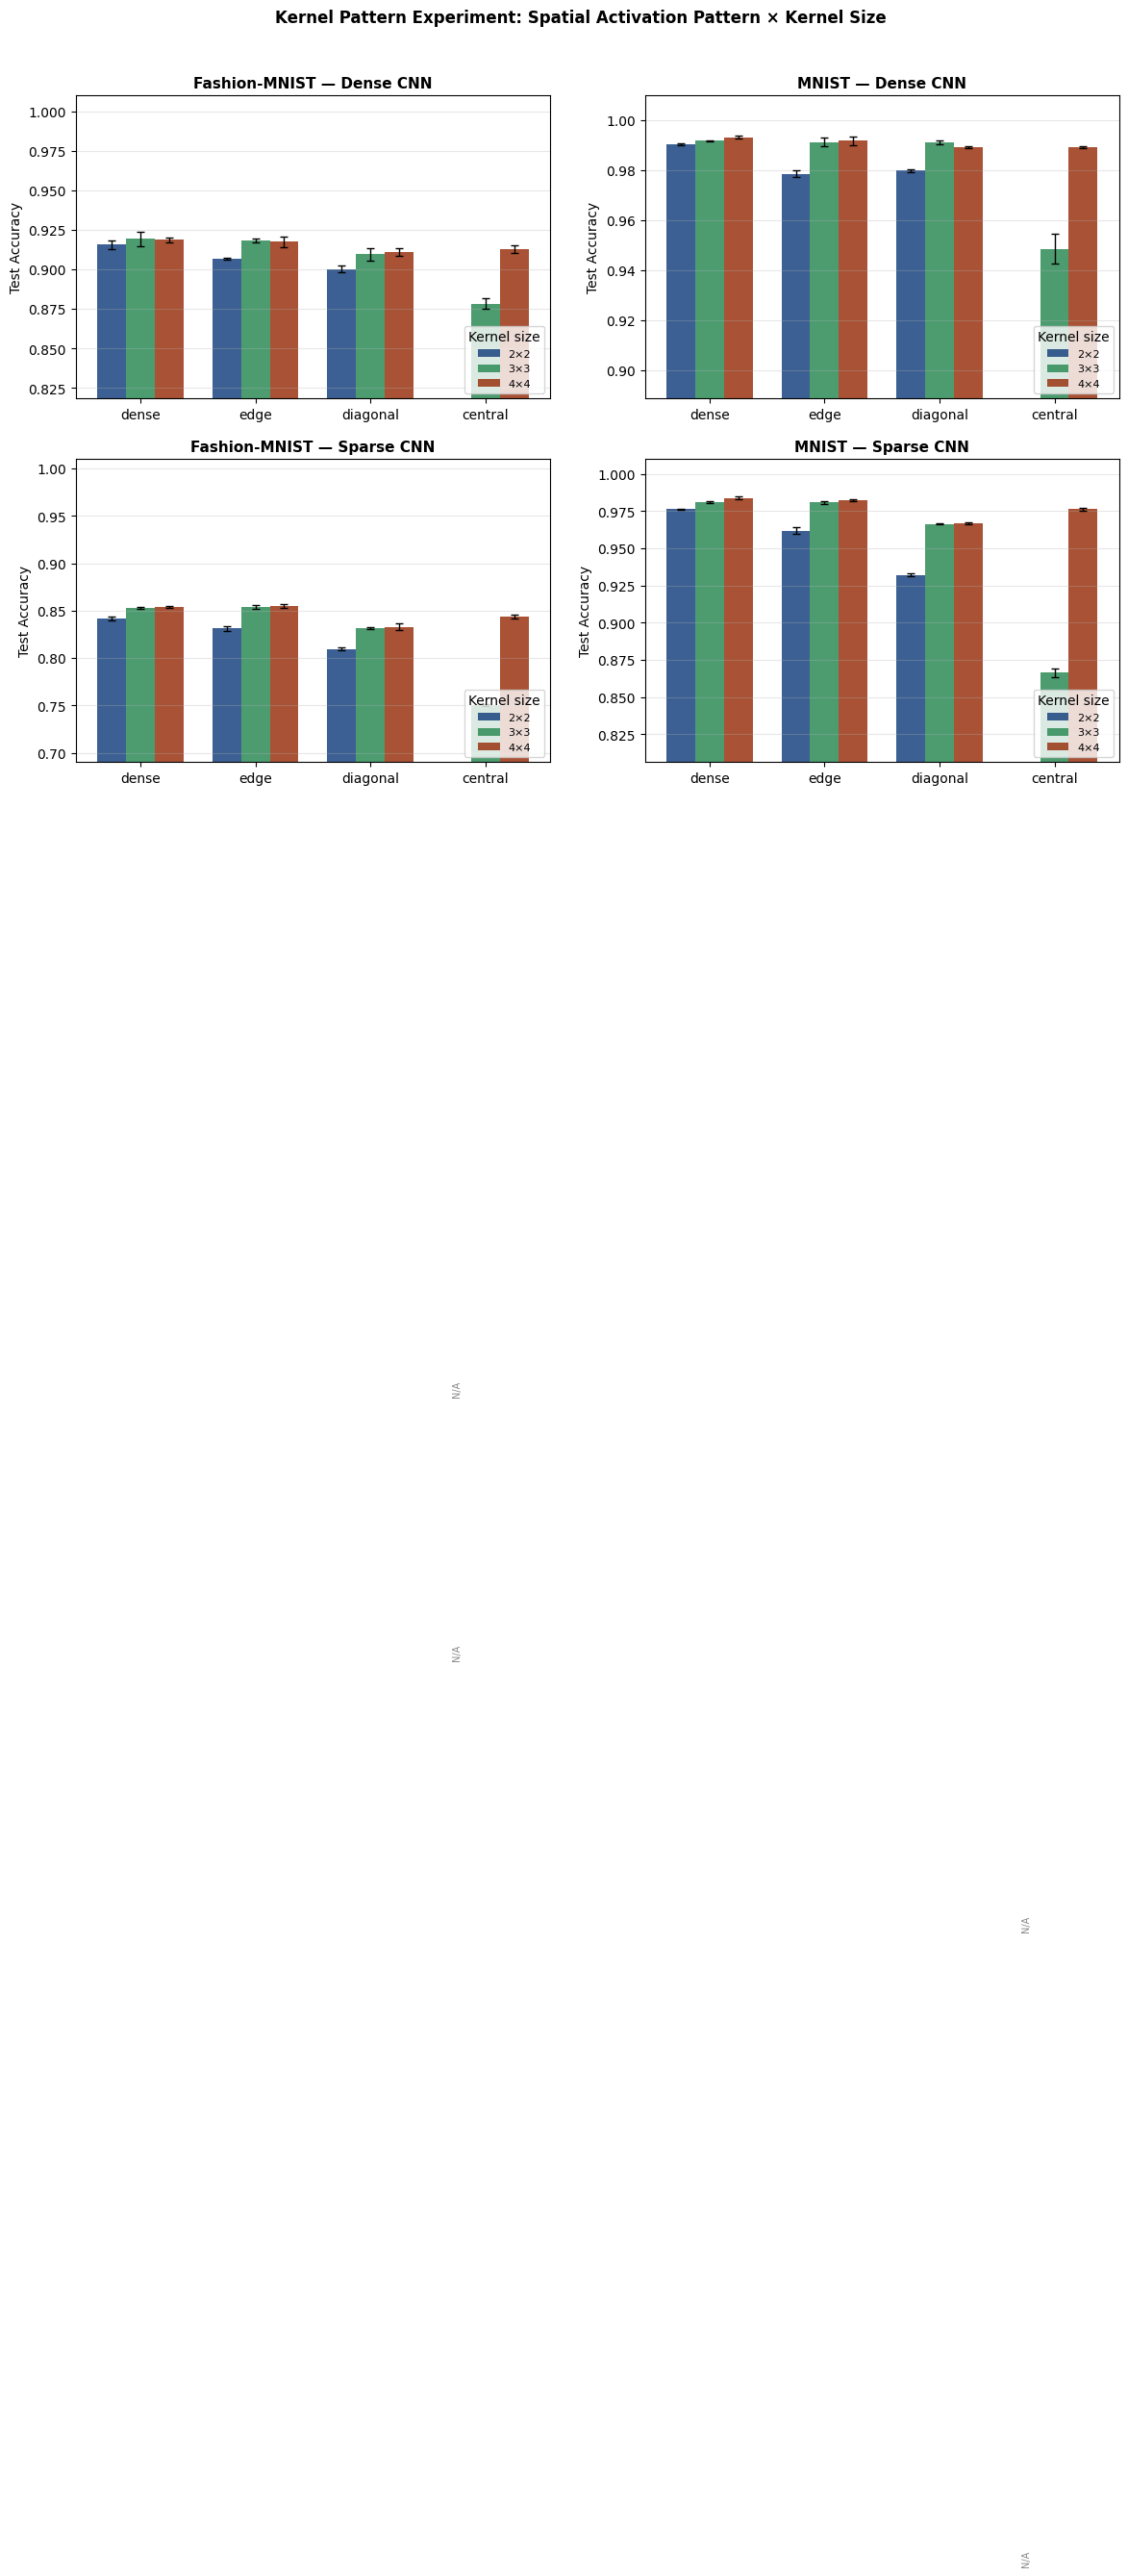

Saved: kernel_patterns.png


In [ ]:
# Cell 6: Kernel pattern experiments

def run_pattern_experiment(X_tr, y_tr, X_te, y_te,
                            model_type, max_active):
    results = {}
    if model_type == "sparse":
        E_te = make_edge_outlines(X_te)
        C_te = extract_coords(E_te, max_active)

    for kc in KERNEL_CONFIGS:
        print(f"  [{model_type}] {kc['name']}: {kc['desc']}")
        seed_accs = []
        cfg = {**BASELINE_CONFIG, "kernel_size": kc["kernel_size"]}

        for seed in range(N_SEEDS):
            tf.random.set_seed(seed); np.random.seed(seed)
            if model_type == "dense":
                model = build_masked_dense_cnn(kc, cfg)
                model.fit(X_tr, y_tr, epochs=EPOCHS,
                          batch_size=cfg["batch_size"],
                          validation_split=VALIDATION_SPLIT, verbose=0)
                _, acc = model.evaluate(X_te, y_te, verbose=0)
            else:
                E_tr  = make_edge_outlines(X_tr)
                C_tr  = extract_coords(E_tr, max_active)
                model = build_sparse_cnn(cfg, max_active,
                                         kernel_mask=kc["mask"])
                model.fit([E_tr, C_tr], y_tr, epochs=EPOCHS,
                          batch_size=cfg["batch_size"],
                          validation_split=VALIDATION_SPLIT, verbose=0)
                _, acc = model.evaluate([E_te, C_te], y_te, verbose=0)

            seed_accs.append(float(acc))
            del model; keras.backend.clear_session(); gc.collect()

        results[kc["name"]] = {
            "mean":        float(np.mean(seed_accs)),
            "std":         float(np.std(seed_accs)),
            "pattern":     kc["pattern"],
            "kernel_size": kc["kernel_size"],
        }
        print(f"    → {results[kc['name']]['mean']:.4f} ± {results[kc['name']]['std']:.4f}")
    return results


# All 4 combinations: 2 datasets × 2 model types
pattern_results = {}
for ds in ["fashion_mnist", "mnist"]:
    X_tr, y_tr, X_te, y_te = load_and_preprocess(ds)
    ma = MAX_ACTIVE_FM if ds == "fashion_mnist" else MAX_ACTIVE_MN
    print(f"\nPATTERN EXPERIMENT: {ds.upper()}")
    for mt in ["dense", "sparse"]:
        pattern_results[(ds, mt)] = run_pattern_experiment(
            X_tr, y_tr, X_te, y_te, mt, ma)


# Results table
for ds in ["fashion_mnist", "mnist"]:
    print(f"\nKERNEL PATTERN RESULTS: {ds.replace('_','-').upper()} (mean ± std, 3 seeds, 100%)")
    print(f"{'Config':<14}  {'Pattern':<10}  {'Size':>4}  {'Dense CNN':>13}  {'Sparse CNN':>13}")
    print("-" * 60)
    for pat in PATTERN_TYPES:
        for ks in KERNEL_SIZE_OPTIONS:
            name = f"{pat}_{ks}x{ks}"
            if name not in pattern_results[(ds, "dense")]:
                continue
            rd = pattern_results[(ds, "dense")][name]
            rs = pattern_results[(ds, "sparse")][name]
            print(f"{name:<14}  {pat:<10}  {ks}x{ks}  "
                  f"{rd['mean']:.4f}±{rd['std']:.3f}  "
                  f"{rs['mean']:.4f}±{rs['std']:.3f}")
        print()


# Plots Figure
def plot_pattern_results():
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    datasets = ["fashion_mnist", "mnist"]
    titles   = ["Fashion-MNIST", "MNIST"]
    ks_colors = {2: "#1A4480", 3: "#2E8B57", 4: "#9A3412"}
    ks_labels = {2: "2×2", 3: "3×3", 4: "4×4"}

    for col, (ds, ds_title) in enumerate(zip(datasets, titles)):
        for row, mt in enumerate(["dense", "sparse"]):
            ax  = axes[row, col]
            res = pattern_results[(ds, mt)]
            x       = np.arange(len(PATTERN_TYPES))
            width   = 0.25
            offsets = np.linspace(-(len(KERNEL_SIZE_OPTIONS)-1)*width/2,
                                   (len(KERNEL_SIZE_OPTIONS)-1)*width/2,
                                   len(KERNEL_SIZE_OPTIONS))

            for i, ks in enumerate(KERNEL_SIZE_OPTIONS):
                means, stds = [], []
                for pat in PATTERN_TYPES:
                    name = f"{pat}_{ks}x{ks}"
                    if name in res:
                        means.append(res[name]["mean"])
                        stds.append(res[name]["std"])
                    else:
                        means.append(0.0)
                        stds.append(0.0)

                ax.bar(x + offsets[i], means, width,
                       yerr=stds, label=ks_labels[ks],
                       color=ks_colors[ks], alpha=0.85,
                       capsize=3, error_kw={"linewidth": 1.0})

                for j, pat in enumerate(PATTERN_TYPES):
                    if f"{pat}_{ks}x{ks}" not in res:
                        ax.text(x[j] + offsets[i], 0.02, "N/A",
                                ha="center", va="bottom",
                                fontsize=7, color="#888888", rotation=90)

            ax.set_xticks(x)
            ax.set_xticklabels(PATTERN_TYPES, fontsize=10)
            ax.set_ylabel("Test Accuracy")
            ax.set_title(f"{ds_title} — {mt.capitalize()} CNN",
                         fontsize=11, fontweight="bold")
            ax.legend(title="Kernel size", fontsize=8, loc="lower right")
            ax.grid(True, axis="y", alpha=0.3)
            all_vals = [v["mean"] for v in res.values() if v["mean"] > 0]
            ax.set_ylim(max(0, min(all_vals) - 0.06), 1.01)

    plt.suptitle(
        "Kernel Pattern Experiment: Spatial Activation Pattern × Kernel Size",
        fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig("kernel_patterns.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: kernel_patterns.png")

plot_pattern_results()


=== LEARNING CURVE: FASHION_MNIST — DENSE ===
  FASHION_MNIST: train (60000, 28, 28, 1), test (10000, 28, 28, 1)

  1% (600 images)
    Seed 0: 0.8022
    Seed 1: 0.7955
    Seed 2: 0.8161
  Mean: 0.8046 ± 0.0086  ✓ saved

  5% (3000 images)
    Seed 0: 0.8548
    Seed 1: 0.8588
    Seed 2: 0.8503
  Mean: 0.8546 ± 0.0035  ✓ saved

  10% (6000 images)
    Seed 0: 0.8611
    Seed 1: 0.8747
    Seed 2: 0.8793
  Mean: 0.8717 ± 0.0077  ✓ saved

  25% (15000 images)
    Seed 0: 0.8955
    Seed 1: 0.8963
    Seed 2: 0.8962
  Mean: 0.8960 ± 0.0004  ✓ saved

  50% (30000 images)
    Seed 0: 0.9084
    Seed 1: 0.9038
    Seed 2: 0.9000
  Mean: 0.9041 ± 0.0034  ✓ saved

  75% (45000 images)
    Seed 0: 0.9098
    Seed 1: 0.9128
    Seed 2: 0.9120
  Mean: 0.9115 ± 0.0013  ✓ saved

  100% (60000 images)
    Seed 0: 0.9170
    Seed 1: 0.9151
    Seed 2: 0.9170
  Mean: 0.9164 ± 0.0009  ✓ saved

=== LEARNING CURVE: FASHION_MNIST — SPARSE ===
  FASHION_MNIST: train (60000, 28, 28, 1), test (10000, 28,

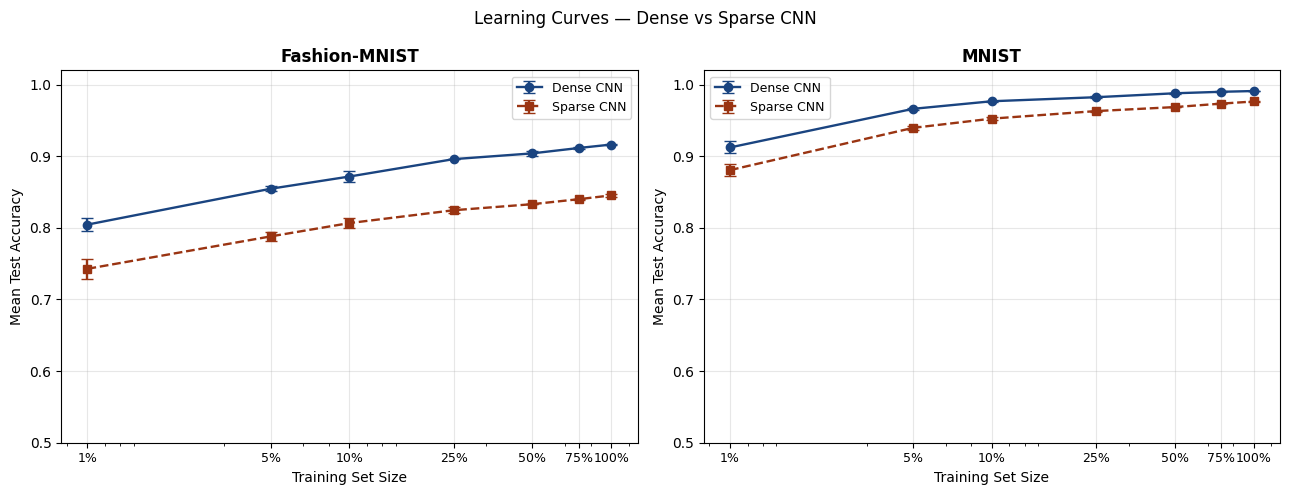

Saved: learning_curves.png


In [ ]:
#Cell 7: Learning curve experiments

#Baseline architecture trained at all 7 sizes × 3 seeds.
#Checkpoints after each size in case the session expires.

def run_learning_curve(dataset_name, model_type, max_active):
    print(f"\nLEARNING CURVE: {dataset_name.upper()} — {model_type.upper()}")
    X_tr, y_tr, X_te, y_te = load_and_preprocess(dataset_name)

    if model_type == "sparse":
        print("  Converting test set to contour outlines (once)...")
        E_te = make_edge_outlines(X_te)
        C_te = extract_coords(E_te, max_active)

    all_accs, all_f1s, ckpt = [], [], []

    for sl, n in zip(SAMPLE_PERCENTAGES, SAMPLE_SIZES):
        print(f"\n  {sl} ({n} images)")
        s_accs, s_f1s = [], []

        for seed in range(N_SEEDS):
            tf.random.set_seed(seed); np.random.seed(seed)
            X_sub, y_sub = stratified_sample(X_tr, y_tr, n, seed)

            if model_type == "dense":
                model = build_dense_cnn(BASELINE_CONFIG)
                model.fit(X_sub, y_sub, epochs=EPOCHS,
                          batch_size=BASELINE_CONFIG["batch_size"],
                          validation_split=VALIDATION_SPLIT, verbose=0)
                _, acc  = model.evaluate(X_te, y_te, verbose=0)
                y_pred  = np.argmax(model.predict(X_te, verbose=0), axis=1)
            else:
                E_sub = make_edge_outlines(X_sub)
                C_sub = extract_coords(E_sub, max_active)
                model = build_sparse_cnn(BASELINE_CONFIG, max_active)
                model.fit([E_sub, C_sub], y_sub, epochs=EPOCHS,
                          batch_size=BASELINE_CONFIG["batch_size"],
                          validation_split=VALIDATION_SPLIT, verbose=0)
                _, acc  = model.evaluate([E_te, C_te], y_te, verbose=0)
                y_pred  = np.argmax(model.predict([E_te, C_te], verbose=0), axis=1)

            report = classification_report(y_te, y_pred,
                                           output_dict=True, zero_division=0)
            f1 = [report[str(c)]["f1-score"] for c in range(10)]
            s_accs.append(float(acc)); s_f1s.append(f1)
            print(f"    Seed {seed}: {acc:.4f}")
            del model; keras.backend.clear_session(); gc.collect()

        all_accs.append(s_accs); all_f1s.append(s_f1s)
        ckpt.append({"size": sl, "n": n, "accs": s_accs, "f1s": s_f1s})
        with open(f"lc_{dataset_name}_{model_type}.json","w") as f:
            json.dump(ckpt, f)
        print(f"  Mean: {np.mean(s_accs):.4f} ± {np.std(s_accs):.4f}  ✓ saved")

    arr_a = np.array(all_accs); arr_f = np.array(all_f1s)
    return {"dataset": dataset_name, "model": model_type,
            "mean_acc": np.mean(arr_a, axis=1),
            "std_acc":  np.std(arr_a,  axis=1),
            "mean_f1":  np.mean(arr_f,  axis=1)}


lc = {}
for ds in ["fashion_mnist","mnist"]:
    ma = MAX_ACTIVE_FM if ds=="fashion_mnist" else MAX_ACTIVE_MN
    lc[(ds,"dense")]  = run_learning_curve(ds, "dense",  ma)
    lc[(ds,"sparse")] = run_learning_curve(ds, "sparse", ma)


#Learning curve table
print("\nLEARNING CURVE: Mean Test Accuracy (±std, 3 seeds)")
print(f"{'Size':>5}  {'FM Dense':>13} {'FM Sparse':>13} {'MN Dense':>13} {'MN Sparse':>13}")
print("-"*60)
for i,(sl,n) in enumerate(zip(SAMPLE_PERCENTAGES,SAMPLE_SIZES)):
    row = f"{sl:>5}"
    for k in [("fashion_mnist","dense"),("fashion_mnist","sparse"),
               ("mnist","dense"),("mnist","sparse")]:
        row += f"  {lc[k]['mean_acc'][i]:.4f}±{lc[k]['std_acc'][i]:.4f}"
    print(row)


# Learning curve figure
def plot_learning_curves():
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    N = np.array(SAMPLE_SIZES)
    colors = {"dense": "#1A4480", "sparse": "#9A3412"}
    markers= {"dense": "o",      "sparse": "s"}
    lines  = {"dense": "-",      "sparse": "--"}

    for ax, ds, title in zip(axes,
                              ["fashion_mnist","mnist"],
                              ["Fashion-MNIST","MNIST"]):
        for mt in ["dense","sparse"]:
            k   = (ds, mt)
            col = colors[mt]; mk = markers[mt]; ls = lines[mt]
            ax.errorbar(N, lc[k]["mean_acc"], yerr=lc[k]["std_acc"],
                        fmt=mk, color=col, linestyle=ls, capsize=4,
                        linewidth=1.7, label=f"{mt.capitalize()} CNN")
        ax.set_xscale("log")
        ax.set_xticks(SAMPLE_SIZES)
        ax.set_xticklabels(SAMPLE_PERCENTAGES, fontsize=9)
        ax.set_xlabel("Training Set Size"); ax.set_ylabel("Mean Test Accuracy")
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_ylim(0.5, 1.02)

    plt.suptitle("Learning Curves: Dense vs Sparse CNN", fontsize=12)
    plt.tight_layout()
    plt.savefig("learning_curves.png", dpi=150, bbox_inches="tight")
    plt.show(); print("Saved: learning_curves.png")

plot_learning_curves()

POWER-LAW FIT RESULTS
Dataset+Model                      A       B       α      R²    N* (δ=0.005)
---------------------------------------------------------------------------
fashion-mnist dense           0.9921  0.6634  0.1973  0.9984       Not found
fashion-mnist sparse          0.9091  0.6209  0.2058  0.9988       Not found
mnist dense                   0.9944  5.4138  0.6550  0.9989           9,219
mnist sparse                  0.9849  2.6291  0.5048  0.9986          21,911


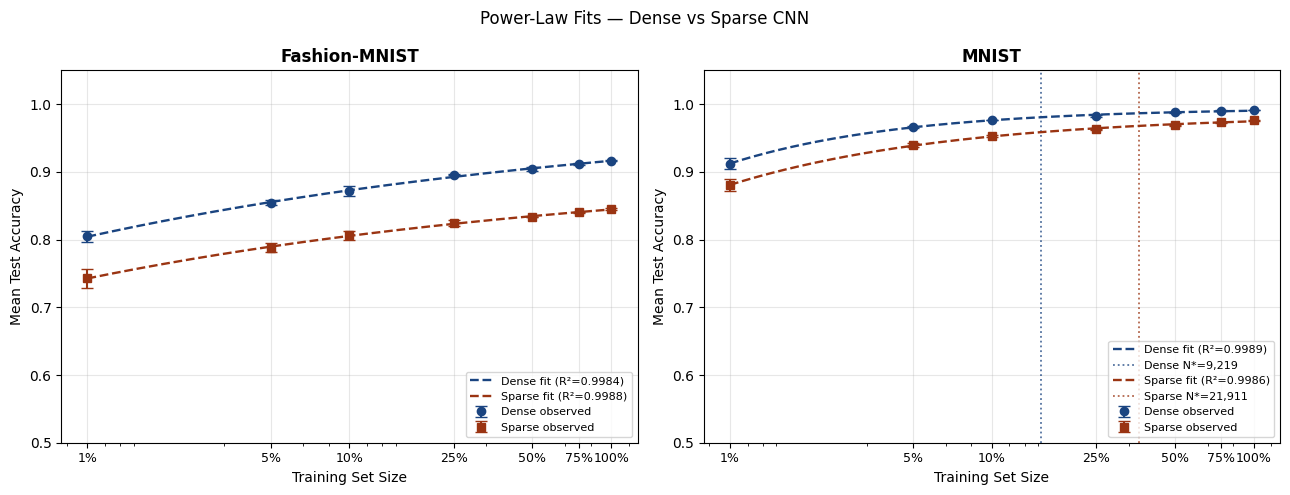

Saved: power_law_fits.png


In [ ]:
#Cell 8: Power-law fitting and plateau analysis

def power_law(N, A, B, alpha):
    """Accuracy(N) = A - B·N^(-alpha)"""
    return A - B * N ** (-alpha)


def fit_power_law(mean_acc):
    """Fit the power-law function by non-linear least squares; fall back to
    a second initial estimate with a higher iteration limit if needed."""
    N = np.array(SAMPLE_SIZES, dtype=float)
    y = np.array(mean_acc,     dtype=float)
    try:
        p, _ = curve_fit(power_law, N, y,
                          p0=[1.0,0.5,0.5],
                          bounds=([0,0,0],[1.5,10,5]), maxfev=10000)
    except RuntimeError:
        p, _ = curve_fit(power_law, N, y, p0=[0.95,2.0,0.3], maxfev=20000)
    A, B, alpha = p
    resid = y - power_law(N, *p)
    r2 = 1 - np.sum(resid**2) / np.sum((y - y.mean())**2)
    return float(A), float(B), float(alpha), float(r2)


def find_plateau(A, B, alpha, delta=0.005):
    """Return the smallest N where doubling the data gains < delta accuracy."""
    grid = np.logspace(np.log10(600), np.log10(500000), 10000)
    for N in grid[:-1]:
        if power_law(2*N, A, B, alpha) - power_law(N, A, B, alpha) < delta:
            return float(N)
    return None


fit = {}
print("POWER-LAW FIT RESULTS")
print(f"{'Dataset+Model':<28} {'A':>7} {'B':>7} {'α':>7} {'R²':>7} {'N* (δ=0.005)':>15}")
print("-"*75)
for (ds,mt), res in lc.items():
    A,B,alpha,r2 = fit_power_law(res["mean_acc"])
    N_star       = find_plateau(A,B,alpha)
    fit[(ds,mt)] = {"A":A,"B":B,"alpha":alpha,"R2":r2,"N_star":N_star}
    label  = f"{ds.replace('_','-')} {mt}"
    n_str  = f"{N_star:,.0f}" if N_star else "Not found"
    print(f"{label:<28} {A:>7.4f} {B:>7.4f} {alpha:>7.4f} {r2:>7.4f} {n_str:>15}")


# Power-law figure
def plot_power_law():
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    N_obs    = np.array(SAMPLE_SIZES)
    N_smooth = np.logspace(np.log10(600), np.log10(60000), 500)
    colors   = {"dense":"#1A4480","sparse":"#9A3412"}
    markers  = {"dense":"o","sparse":"s"}

    for ax, ds, title in zip(axes,
                              ["fashion_mnist","mnist"],
                              ["Fashion-MNIST","MNIST"]):
        for mt in ["dense","sparse"]:
            k   = (ds, mt); col = colors[mt]; mk = markers[mt]
            fr  = fit[k]
            ax.errorbar(N_obs, lc[k]["mean_acc"], yerr=lc[k]["std_acc"],
                        fmt=mk, color=col, capsize=4,
                        label=f"{mt.capitalize()} observed")
            ax.plot(N_smooth, power_law(N_smooth,fr["A"],fr["B"],fr["alpha"]),
                    color=col, linestyle="--", linewidth=1.7,
                    label=f"{mt.capitalize()} fit (R²={fr['R2']:.4f})")
            if fr["N_star"]:
                ax.axvline(fr["N_star"], color=col, linestyle=":",
                           linewidth=1.3, alpha=0.75,
                           label=f"{mt.capitalize()} N*={fr['N_star']:,.0f}")
        ax.set_xscale("log")
        ax.set_xticks(SAMPLE_SIZES)
        ax.set_xticklabels(SAMPLE_PERCENTAGES, fontsize=9)
        ax.set_xlabel("Training Set Size"); ax.set_ylabel("Mean Test Accuracy")
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.legend(fontsize=8, loc="lower right")
        ax.grid(True, alpha=0.3); ax.set_ylim(0.5, 1.05)

    plt.suptitle("Power-Law Fits: Dense vs Sparse CNN", fontsize=12)
    plt.tight_layout()
    plt.savefig("power_law_fits.png", dpi=150, bbox_inches="tight")
    plt.show(); print("Saved: power_law_fits.png")

plot_power_law()

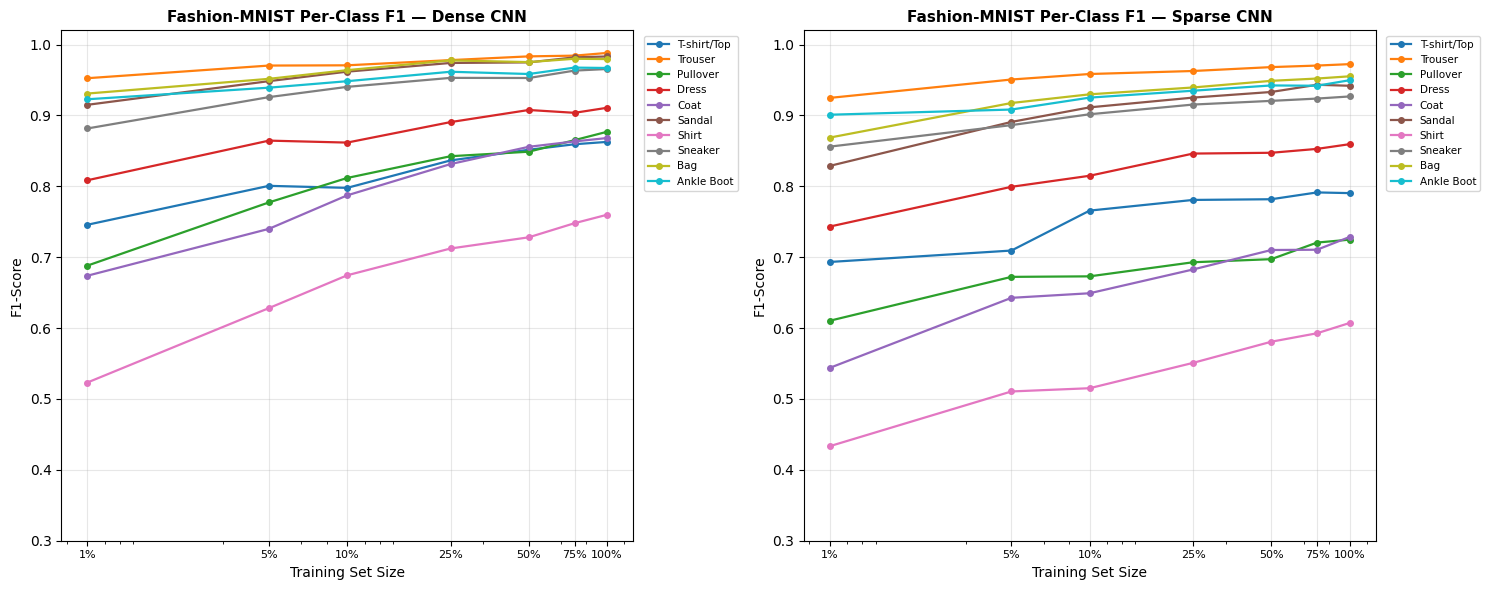

Saved: f1_per_class.png

F1 Gain 1%→100% — Fashion-MNIST DENSE CNN
Class              F1@1%   F1@100%    Gain
------------------------------------------
Shirt              0.523     0.760   0.237
Coat               0.674     0.868   0.194
Pullover           0.688     0.877   0.189
T-shirt/Top        0.746     0.863   0.117
Dress              0.808     0.911   0.102
Sneaker            0.882     0.965   0.084
Sandal             0.915     0.983   0.068
Bag                0.931     0.979   0.049
Ankle Boot         0.923     0.967   0.044
Trouser            0.952     0.988   0.036

F1 Gain 1%→100% — Fashion-MNIST SPARSE CNN
Class              F1@1%   F1@100%    Gain
------------------------------------------
Coat               0.544     0.728   0.185
Shirt              0.433     0.607   0.174
Dress              0.743     0.859   0.116
Pullover           0.610     0.725   0.114
Sandal             0.829     0.942   0.113
T-shirt/Top        0.693     0.790   0.097
Bag                0.869     

In [ ]:
#Cell 9: Per-class F1-score analysis for Fashion-MNIST

def plot_f1_analysis():
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    colors = plt.cm.tab10(np.linspace(0, 1, 10))

    for ax, mt in zip(axes, ["dense","sparse"]):
        mf1 = lc[("fashion_mnist", mt)]["mean_f1"]  # shape (7, 10)
        for cls in range(10):
            ax.plot(SAMPLE_SIZES, mf1[:, cls],
                    marker="o", markersize=4, linewidth=1.6,
                    color=colors[cls], label=FMNIST_CLASS_NAMES[cls])
        ax.set_xscale("log")
        ax.set_xticks(SAMPLE_SIZES)
        ax.set_xticklabels(SAMPLE_PERCENTAGES, fontsize=8)
        ax.set_xlabel("Training Set Size"); ax.set_ylabel("F1-Score")
        ax.set_title(f"Fashion-MNIST Per-Class F1 — {mt.capitalize()} CNN",
                     fontsize=11, fontweight="bold")
        ax.legend(fontsize=7.5, bbox_to_anchor=(1.01,1), loc="upper left")
        ax.grid(True, alpha=0.3); ax.set_ylim(0.3, 1.02)

    plt.tight_layout()
    plt.savefig("f1_per_class.png", dpi=150, bbox_inches="tight")
    plt.show(); print("Saved: f1_per_class.png")


def print_f1_gain_table():
    for mt in ["dense","sparse"]:
        mf1    = lc[("fashion_mnist", mt)]["mean_f1"]
        gains  = mf1[-1] - mf1[0]
        order  = np.argsort(gains)[::-1]
        print(f"\nF1 Gain 1%→100% — Fashion-MNIST {mt.upper()} CNN")
        print(f"{'Class':<15} {'F1@1%':>8} {'F1@100%':>9} {'Gain':>7}")
        print("-"*42)
        for idx in order:
            print(f"{FMNIST_CLASS_NAMES[idx]:<15}"
                  f" {mf1[0,idx]:>8.3f} {mf1[-1,idx]:>9.3f}"
                  f" {gains[idx]:>7.3f}")

plot_f1_analysis()
print_f1_gain_table()